**EDA on our merged OULAD**

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('ouladmerg.csv')

We look at what columns there are, and divide these into columns related to the unique student, columns related to VLE interactions, and columns related to assessments.

In [6]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'date', 'forumng',
       'homepage', 'oucontent', 'subpage', 'url', 'resource', 'glossary',
       'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 'sharedsubpage',
       'questionnaire', 'page', 'externalquiz', 'ouwiki', 'dualpane',
       'repeatactivity', 'folder', 'htmlactivity', 'id_assessment',
       'is_banked', 'score', 'assessment_type', 'due_date', 'weight',
       'module_presentation_length', 'gender', 'region', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')

In [7]:
tag_feats = df.columns[:3]
module_feats = [df.columns[30]]
dataline_feats = ['date']
vle_feats = df.columns[4:24]
assess_feats = df.columns[24:30]
student_feats = df.columns[31:] 
tag_feats, student_feats, module_feats, vle_feats, assess_feats

(Index(['id_student', 'code_module', 'code_presentation'], dtype='object'),
 Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
        'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result',
        'date_registration', 'date_unregistration'],
       dtype='object'),
 ['module_presentation_length'],
 Index(['forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
        'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
        'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
        'dualpane', 'repeatactivity', 'folder', 'htmlactivity'],
       dtype='object'),
 Index(['id_assessment', 'is_banked', 'score', 'assessment_type', 'due_date',
        'weight'],
       dtype='object'))

**Missing data**

We study / visualize how much of our data is missing.

(Note: no data is missing from features in `tag_feats`, `module_feats`, `date`, `vle_feats`)

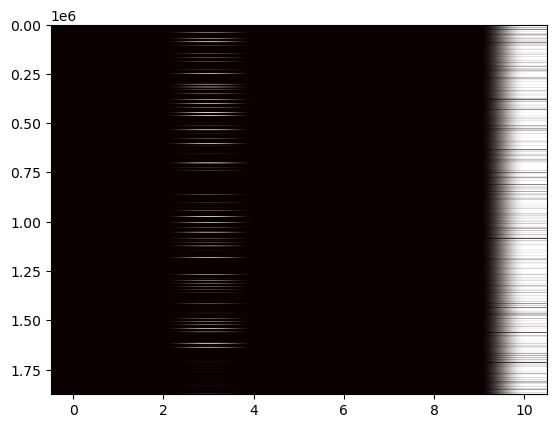

In [8]:
plt.imshow(df[student_feats].isnull(), cmap='hot', aspect='auto')

There are a few missing `imd_band`s and lots of missing `date_unregistration`s.

In [9]:
def how_missing(feature, df):
    m = sum(df[feature].isnull())
    return (m, f"{(m / len(df)):.4f}")

In [10]:
print(how_missing('imd_band',df),  how_missing('date_unregistration',df))

(98792, '0.0527') (1706150, '0.9097')


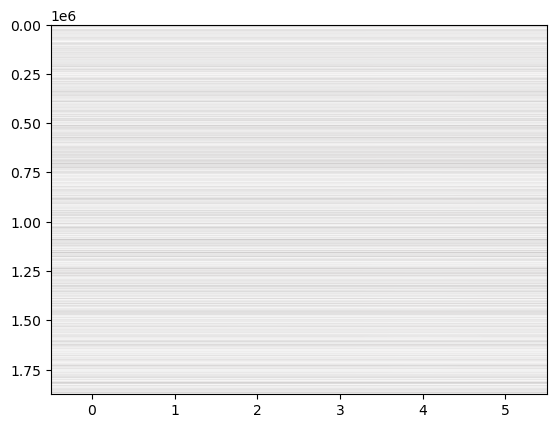

In [11]:
plt.imshow(df[assess_feats].isnull(), cmap='hot', aspect='auto')

Lots of missing `assess_feats`; it seems all these correspond to data lines where students have VLE-type interactions but not assessment interactions.

In [12]:
print(how_missing('id_assessment',df),  how_missing('assessment_type', df), how_missing('score',df))

(1701584, '0.9073') (1701584, '0.9073') (1701757, '0.9074')


In [13]:
df[df.id_assessment.isnull() & ~df.score.isnull()]

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,...,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration


This resolves the mystery of the missing `score` fields: `score`s come from assessments; the small number of rows which are missing `score`s but not other `assess_feat` features probably come from students who did / submitted an assignment but did not receive a score on it for various reasons. We remark that these are all tutor-marked modules, across all modules and all presentations. 

In [14]:
df[~df.id_assessment.isnull() & df.score.isnull()].assessment_type.describe()

count     173
unique      1
top       TMA
freq      173
Name: assessment_type, dtype: object

In [15]:
df[~df.id_assessment.isnull() & df.score.isnull()].code_module.describe()

count     173
unique      7
top       BBB
freq       53
Name: code_module, dtype: object

In [16]:
df[~df.id_assessment.isnull() & df.score.isnull()].code_presentation.describe()

count       173
unique        4
top       2013B
freq         48
Name: code_presentation, dtype: object

For ease of processing (especially given the structure of the missing features), I am going to split into VLE and assessment dataframes. We will want to keep student data in both.

In [17]:
common_feats = list(tag_feats) + list(student_feats) + list(module_feats) + list(dataline_feats)
df_vle = df[df.id_assessment.isnull()][common_feats + list(vle_feats)]
df_assess = df[~df.id_assessment.isnull()][common_feats + list(assess_feats)]

In [18]:
df_vle[vle_feats].sample(3)

,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity
191267,14,5,13,1,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0
109708,0,1,3,15,0,3,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0
573464,0,4,1,3,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0


In [19]:
df_assess.sample(3)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,date_unregistration,module_presentation_length,date,id_assessment,is_banked,score,assessment_type,due_date,weight
1126664,608243,EEE,2013J,M,South Region,A Level or Equivalent,80-90%,0-35,0,60,...,-35.0,NaN,268,67.0,30710.0,0.0,98.0,TMA,68.0,28.0
232942,357219,FFF,2013B,F,London Region,A Level or Equivalent,50-60%,0-35,1,120,...,-21.0,NaN,240,19.0,34860.0,0.0,92.0,TMA,19.0,12.5
1614006,693160,FFF,2014J,M,Yorkshire Region,Lower Than A Level,80-90%,0-35,0,60,...,-28.0,NaN,269,134.0,34902.0,0.0,74.0,TMA,136.0,25.0


**Aggregation strategy**

For the rest of the notebook, we will look at data aggregated at two levels: (i) for the three weeks; (ii) for the first third of the presentation.

*First 3 week data*

We next merge all data rows correspond to each (student, module, presentation).

In [57]:
cutoff = 22

In [59]:
df3w_vle = df_vle[df_vle.date<cutoff].drop(['date'], axis=1)
X1 = df3w_vle.drop(student_feats,axis=1).groupby(list(tag_feats)).sum()
X2y = df3w_vle[list(tag_feats)+list(student_feats)].groupby(list(tag_feats)).last()
df3w_vle = pd.concat([X1,X2y],axis=1)

In [61]:
df3w_vle[vle_feats].sample()

,,,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,
532745,DDD,2013B,90,102,16,75,45,33,0,0,0,0.0,4,0,0,0,13,56,0,0,0,0


**Correlations**

We next look at correlations between the interaction features, and then between engineered features (and interaction features).

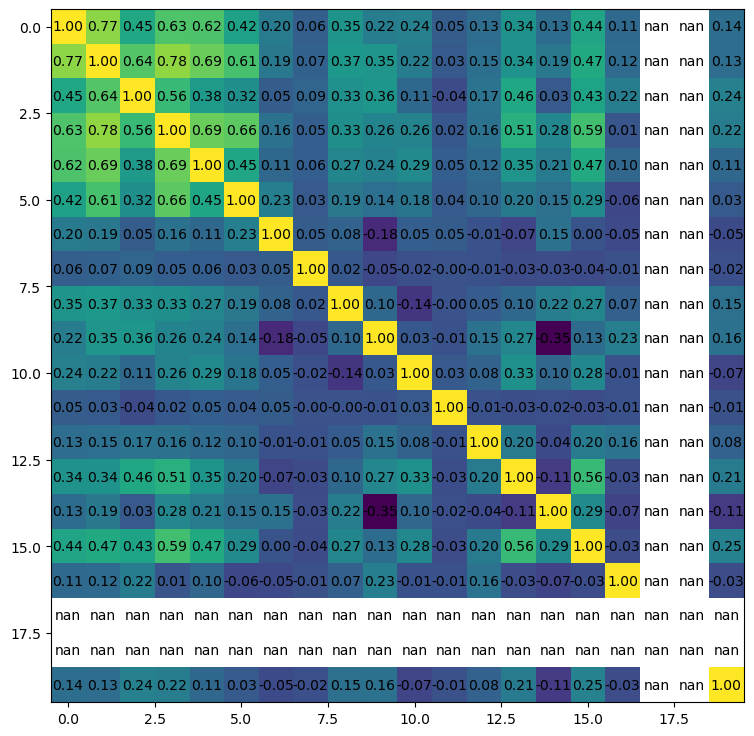

In [ ]:
corrs = df3w_vle[vle_feats].corr(method='spearman')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')

 The first six features appear relatively correlated with each other. `homepage` (the second feature) and `subpage` (the fourth feature), in particular, appear quite correlated with a number of other features and possibly should be disregarded (or maybe `homepage` should maybe be read as a sort of "total interaction" feature and is maybe redundant if we include `subpage` and/or `url`.). The remaining correlations do not seem too high. 

In [63]:
df3w_vle.repeatactivity.describe()

count    28520.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: repeatactivity, dtype: float64

In [64]:
df3w_vle.folder.describe()

count    28520.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: folder, dtype: float64

Two of these columns *never* appear (!); we should just drop these. (This also explains why the correlations with these columns are zero --- those columns have zero variance!)

In [67]:
df3w_vle.drop(['folder','repeatactivity'],axis=1,inplace=True)

**Engineered features** 

Now we add engineered features.

In [68]:
vle_feats_n = list(vle_feats[:-3]) + [vle_feats[-1]]
df3w_vle['total_vle']=df3w_vle[vle_feats_n].sum(axis=1)

In [70]:
df3w_vle['vle_richness'] = (df3w_vle[vle_feats_n] > 0).sum(axis=1)


In [71]:
from scipy.stats import entropy

def shannon_entropy(row):
    counts = row.values.astype(float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    proportions = counts / counts.sum()
    return entropy(proportions, base=2)

df3w_vle['vle_entropy'] = df3w_vle[vle_feats_n].apply(shannon_entropy, axis=1)

In [72]:
# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage']
collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki']

#student_totals = df.groupby(['id_student', 'code_module', 'code_presentation'])[vle_feats_n].sum()

# Assessment focus
df3w_vle['assessment_focus'] = df3w_vle[assessment_types].sum(axis=1) / df3w_vle.total_vle
df3w_vle['content_focus'] = df3w_vle[content_types].sum(axis=1) / df3w_vle.total_vle
df3w_vle['collab_focus'] = df3w_vle[collaborative_types].sum(axis=1) / df3w_vle.total_vle
#collaborative_focus = collaborative_focus.fillna(0).rename('collaborative_focus_ratio')

In [73]:
df_assess["rel_submit_date"] = df_assess["due_date"] - df_assess["date"]
df_assess["submission_type"] = np.where(df_assess["rel_submit_date"] < 0, "Late", "Early")

In [74]:
assess_freq = df_assess[df_assess.date < cutoff].groupby(list(tag_feats)).size().rename('assess_freq')
avg_score = df_assess[df_assess.date < cutoff][list(tag_feats)+['score']].groupby(list(tag_feats)).mean()
avg_early = df_assess[df_assess.date < cutoff][list(tag_feats)+['rel_submit_date']].groupby(list(tag_feats)).mean()

submission_type_counts = (
    df_assess[(df_assess.date < cutoff) & (df_assess.assessment_type != "Exam")]
    .groupby(list(tag_feats)+["submission_type"])
    .size()
    .unstack(fill_value=0)  # columns will be 'Early' and 'Late'
)
if "Late" in submission_type_counts: 
    avg_early["prop_early"] = submission_type_counts["Early"] / (submission_type_counts["Early"] + submission_type_counts["Late"])
else: 
    avg_early["prop_early"] = 1

In [75]:
df3w_assess = pd.concat([assess_freq,avg_score,avg_early],axis=1)


In [76]:
df3w_assess.sample(3)

,,,assess_freq,score,rel_submit_date,prop_early
id_student,code_module,code_presentation,,,,
441954,FFF,2013B,1,64.0,4.0,1.0
627236,DDD,2014J,1,85.0,1.0,1.0
571776,CCC,2014B,1,90.0,-2.0,0.0


In [82]:
df3w = pd.concat([df3w_vle,df3w_assess],axis=1)

In [85]:
df3w = df3w.drop('module_presentation_length',axis=1)

In [93]:
df3w[vle_feats_n] = df3w[vle_feats_n].fillna(0)
zerofills = ['score','assess_freq','rel_submit_date',
             'assessment_focus','content_focus','collab_focus','total_vle',
             'vle_richness','vle_entropy','prop_early']
df3w[zerofills] = df3w[zerofills].fillna(0)
df3w = df3w.dropna(subset=['gender','imd_band'])

In [94]:
df3w.tail(3)

,,,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,...,vle_entropy,assessment_focus,content_focus,collab_focus,assess_freq,score,rel_submit_date,prop_early,std_regularity,days_active
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,,
2698535,EEE,2013J,18.0,26.0,107.0,3.0,4.0,0.0,0.0,0.0,0.0,88.0,...,1.845799,0.357724,0.556911,0.073171,0.0,0.0,0.0,0.0,2.838053,12
2698577,BBB,2014J,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.000000,0.000000,1.000000,0.000000,1.0,100.0,0.0,1.0,0.000000,2
2698588,BBB,2014J,5.0,31.0,29.0,6.0,2.0,7.0,0.0,0.0,1.0,0.0,...,2.102413,0.000000,0.851852,0.074074,1.0,100.0,1.0,1.0,1.516575,6


In [95]:
# Add (overall) regularity features
def std_regularity(df, student_id_col=list(tag_feats), date_col='date'):
    return df.groupby(student_id_col)[date_col].apply(
        lambda x: x.sort_values().diff().std())    

# Lower values = more regular logins
# Higher values = more intermittent/irregular
df3w["std_regularity"] = std_regularity(df[df.date < cutoff]).fillna(0)
df3w["days_active"] = df[df.date < cutoff].groupby(list(tag_feats)).date.nunique()


C:\Users\zhu_f\AppData\Local\Temp\ipykernel_18988\3943398789.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3w["std_regularity"] = std_regularity(df[df.date < cutoff]).fillna(0)
C:\Users\zhu_f\AppData\Local\Temp\ipykernel_18988\3943398789.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3w["days_active"] = df[df.date < cutoff].groupby(list(tag_feats)).date.nunique()


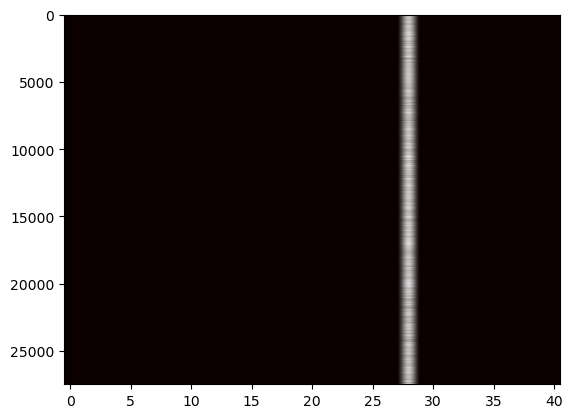

In [96]:
plt.imshow(df3w.isnull(), cmap='hot', aspect='auto')

Let us now examine correlation between engineered features (+ interaction features)

In [97]:
engineered_feats = df3w.columns[-12:]
engineered_feats

Index(['total_vle', 'vle_richness', 'vle_entropy', 'assessment_focus',
       'content_focus', 'collab_focus', 'assess_freq', 'score',
       'rel_submit_date', 'prop_early', 'std_regularity', 'days_active'],
      dtype='object')

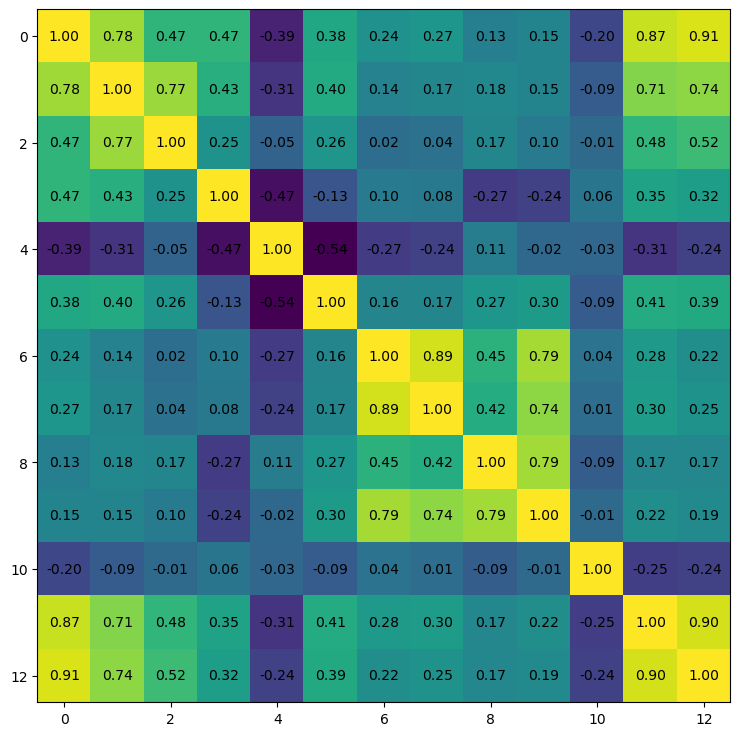

In [ ]:
corrs = df3w[list(engineered_feats)+['homepage']].corr(method='spearman')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')


We observe that `vle_total`, `vle_richness`, `days_active`, and `homepage` are all highly correlated with one another. `vle_richness` is also quite correlated with `vle_entropy`. Maybe we can drop some of these features.

Also, the assessment features `assess_freq`, `score`, `rel_submit_date`, `prop_early` are highly correlated with one another. We could probably drop some of them (maybe `assess_freq` and `prop_early`). 

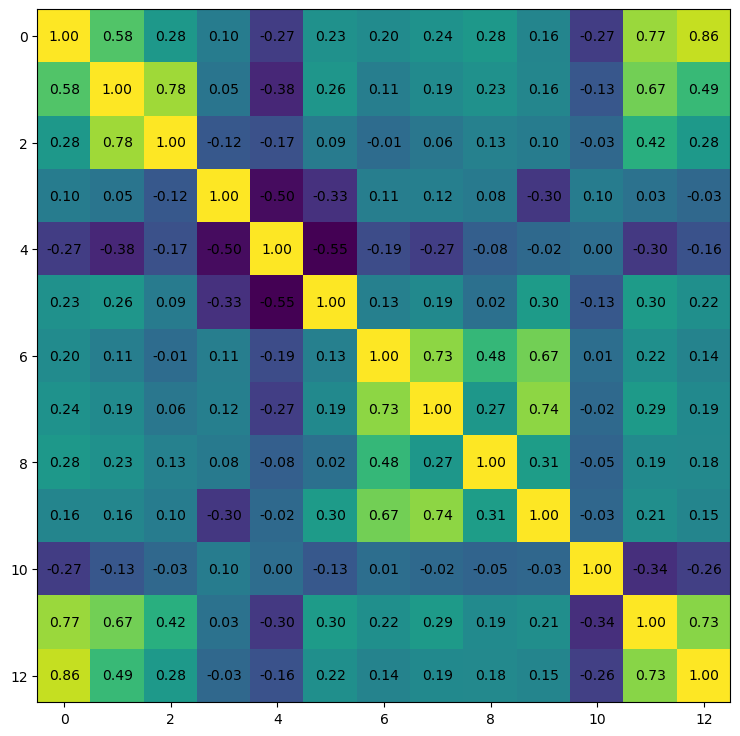

In [102]:
corrs = df3w[list(engineered_feats)+['homepage']].corr(method='pearson')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')

**Distribution of features**

We previously observed that the interaction features appear to be exponentially / geometrically distributed.

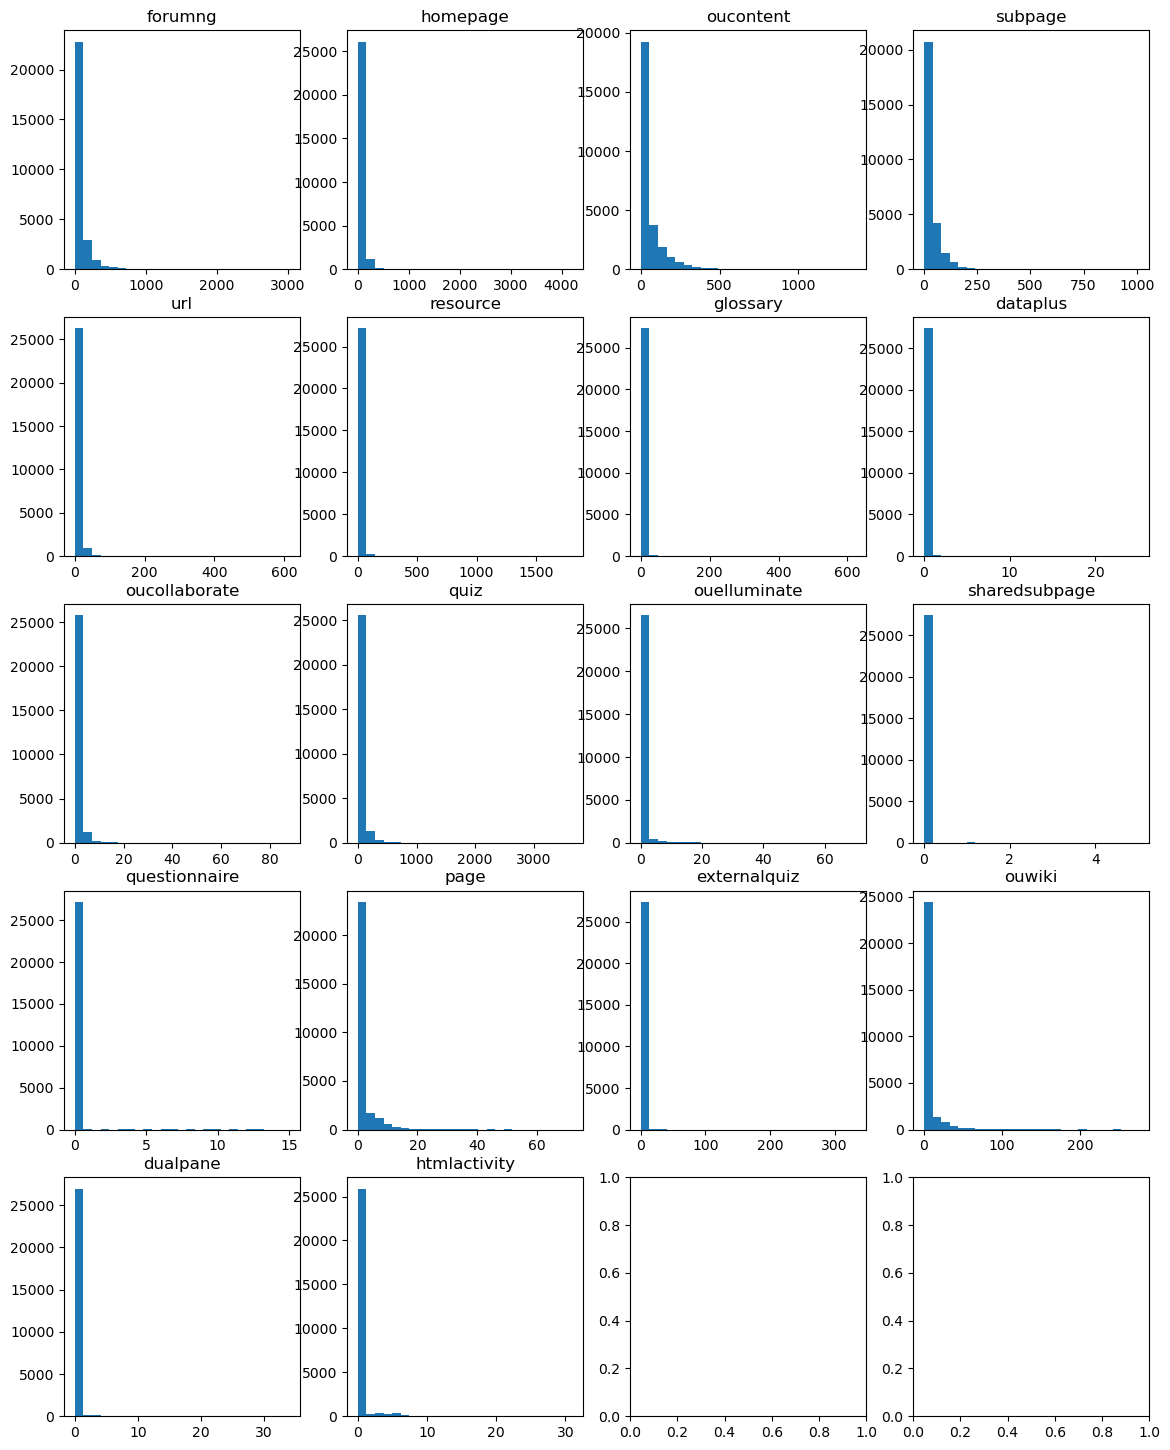

In [109]:
fig, axs = plt.subplots(nrows=5,ncols=4, figsize=(14,18))

for idx, feature in enumerate(vle_feats_n): 
    y, x = idx//4, idx%4
    axs[y, x].hist(df3w[feature],bins=25)
    axs[y, x].set_title(feature)

In [105]:
n = len(df3w)
print("Feature / # / % of students with no instances")
for feature in vle_feats_n:
    z = df3w[feature]
    students_wo_feature = len(z[z==0])
    print(feature, "/", students_wo_feature, "/", students_wo_feature/n)

Feature / # / % of students with no instances
forumng / 5406 / 0.1967463696910143
homepage / 95 / 0.0034574371292353605
oucontent / 3780 / 0.13756960366852278
subpage / 2177 / 0.07922990137205663
url / 7814 / 0.28438330239836956
resource / 3543 / 0.12894420788295666
glossary / 24262 / 0.8829930487316665
dataplus / 27364 / 0.9958874695199621
oucollaborate / 21359 / 0.7773410488772428
quiz / 15377 / 0.5596316919605488
ouelluminate / 25864 / 0.941296356953088
sharedsubpage / 27413 / 0.9976707791971468
questionnaire / 27164 / 0.9886086545110456
page / 21383 / 0.7782145066783128
externalquiz / 23571 / 0.8578447428758598
ouwiki / 21107 / 0.768169741966008
dualpane / 26667 / 0.970520799213888
htmlactivity / 25682 / 0.934672635294974


What if we took logarithms?

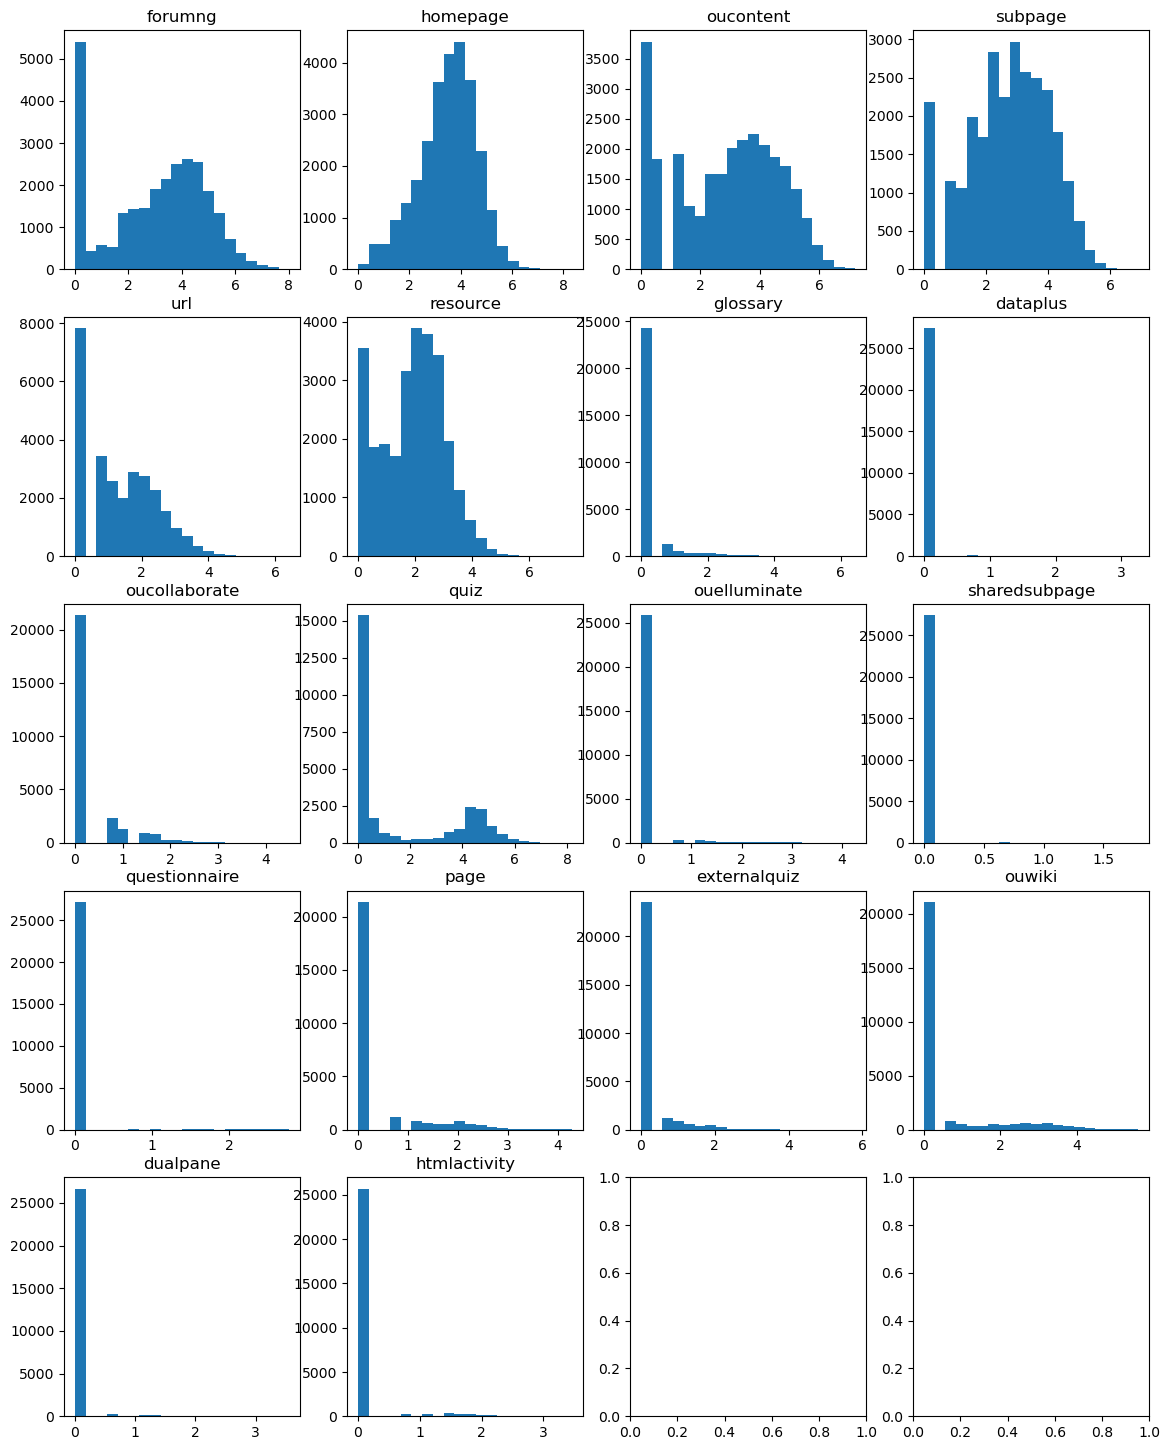

In [107]:
fig, axs = plt.subplots(nrows=5,ncols=4, figsize=(14,18))

for idx, feature in enumerate(vle_feats_n): 
    y, x = idx//4, idx%4
    axs[y, x].hist((df3w[feature]+1).apply(np.log),bins=20)
    axs[y, x].set_title(feature)

I almost feels like it makes sense to discard the features with lots of zeros --- all but `forumng`,`homepage`, `oucontent`, `subpage`, `url`, `resource`. Maybe we can replace the other features with a simple 0 / 1 flag (did the student use the resource during the time period or not?)

**Distribution of features**

We next look at the distribution of engineered features.

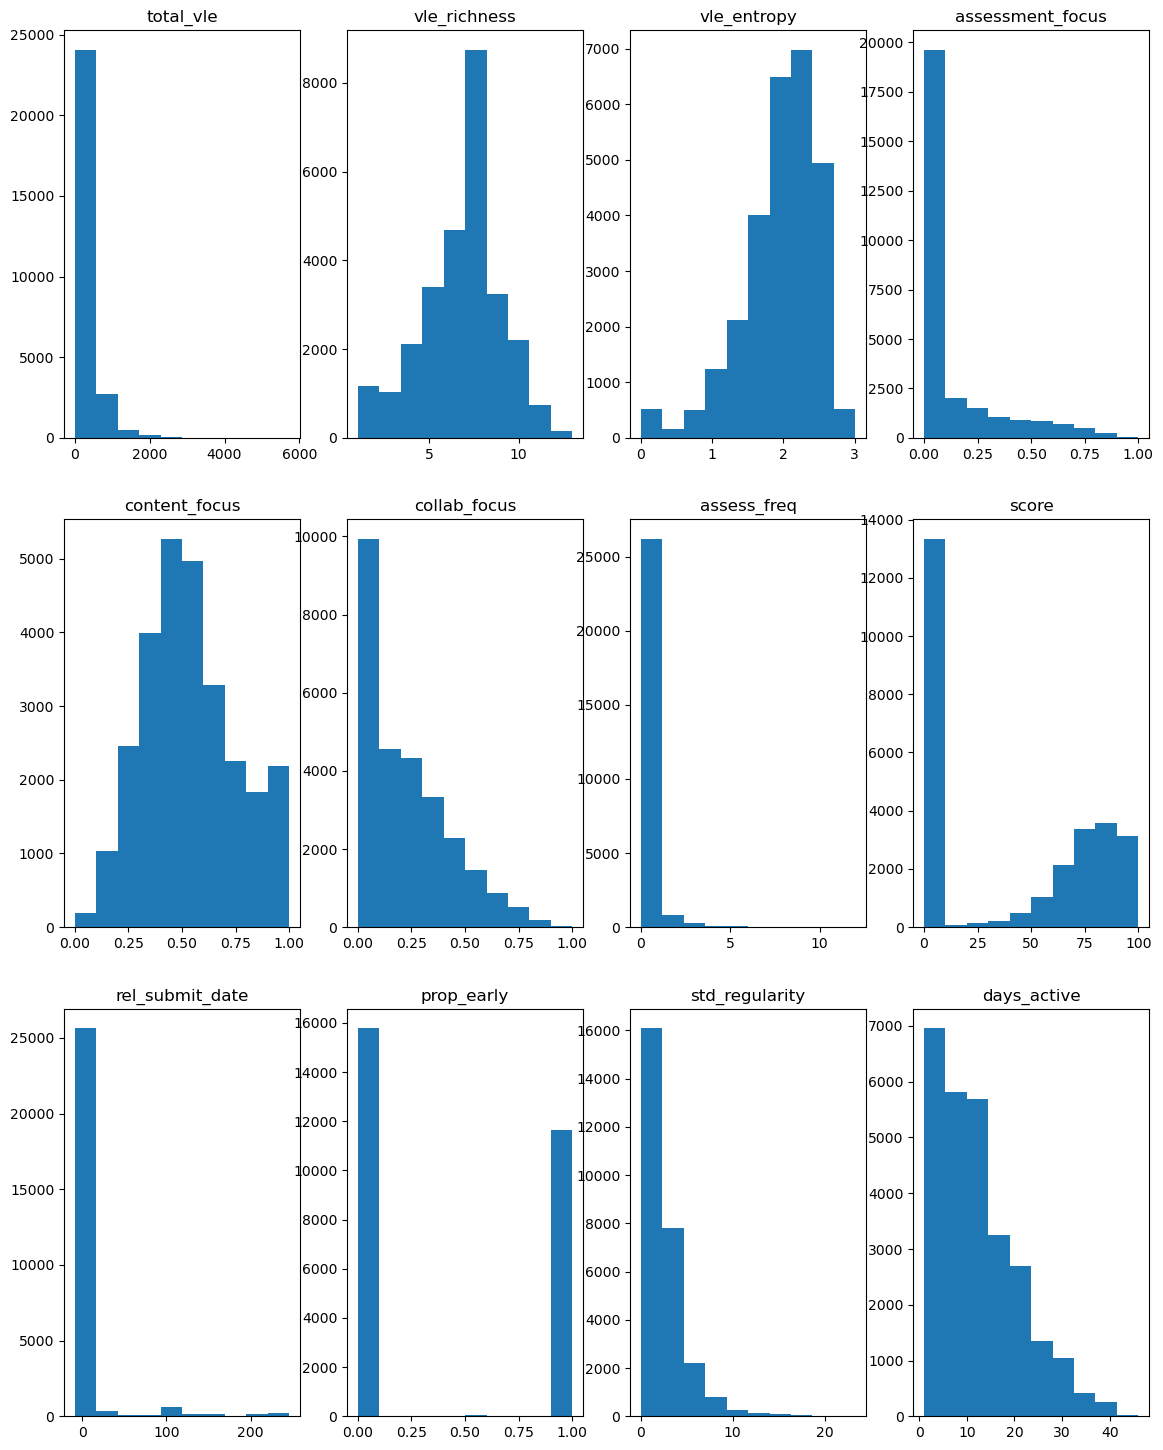

In [108]:
fig, axs = plt.subplots(nrows=3,ncols=4, figsize=(14,18))

for idx, feature in enumerate(engineered_feats): 
    y, x = idx//4, idx%4
    axs[y, x].hist(df3w[feature])
    axs[y, x].set_title(feature)

**VIF analysis for multicollinearity**

In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [ ]:
vif_df3w = pd.DataFrame()
feats = list(df3w.columns[:18])+list(df3w.columns[29:])
vif_df3w["feature"] = feats
vif_df3w["VIF"] = [vif(df3w[feats].values,i) for i in range(len(feats))]

In [128]:
vif_df3w

,feature,VIF
0,forumng,inf
1,homepage,inf
2,oucontent,inf
3,subpage,inf
4,url,inf
5,resource,inf
6,glossary,inf
7,dataplus,inf
8,oucollaborate,inf
9,quiz,inf


That's ... incredibly bad. Hmm.

It would appear that `total_vle` is highly correlated with the individual VLE features.

In [141]:
def restricted_vif(restrict_feats, df=df3w):
    vif_df3wr = pd.DataFrame()
    vif_df3wr["feature"] = restrict_feats
    vif_df3wr["VIF"] = [vif(df[restrict_feats].values,i) for i in range(len(restrict_feats))]
    return vif_df3wr

In [148]:
restricted_vif(['forumng', 'oucontent','subpage','url','resource','quiz','total_vle'])

,feature,VIF
0,forumng,21.984722
1,oucontent,9.409387
2,subpage,7.251025
3,url,2.697898
4,resource,1.835613
5,quiz,6.941723
6,total_vle,96.798916


In [ ]:
restricted_vif(['forumng', 'oucontent','subpage','url','resource','quiz','vle_entropy',
                  'assessment_focus','content_focus','collab_focus',
                  'assess_freq','score','rel_submit_date','std_regularity'])

,feature,VIF
0,forumng,2.342300
1,oucontent,2.195273
2,subpage,4.249037
3,url,2.326594
4,resource,1.593268
5,quiz,2.398209
6,vle_entropy,14.759279
7,assessment_focus,2.884039
8,content_focus,6.663080
9,collab_focus,4.058573


`vle_entropy` may also be correlated with the three focus features --- those three focus features together may already capture most of the same information captured by `vle_entropy`.

In [146]:
restricted_vif(['vle_entropy',
                  'assessment_focus','content_focus','collab_focus'])

,feature,VIF
0,vle_entropy,9.668808
1,assessment_focus,1.498019
2,content_focus,5.287664
3,collab_focus,2.618576


While we're at it, we may as well test our hypothesis about the collinearity of the assessment features.

In [149]:
restricted_vif(['assess_freq', 'score', 'rel_submit_date', 'prop_early'])

,feature,VIF
0,assess_freq,4.805662
1,score,5.403593
2,rel_submit_date,1.406009
3,prop_early,4.109460


In [152]:
restricted_vif(['forumng', 'oucontent','subpage','url','resource','quiz',
                  'assessment_focus','content_focus','collab_focus',
                  'assess_freq','score','rel_submit_date','prop_early','std_regularity'])

,feature,VIF
0,forumng,2.233540
1,oucontent,2.220001
2,subpage,3.539584
3,url,2.322686
4,resource,1.593861
5,quiz,2.434414
6,assessment_focus,2.883657
7,content_focus,2.877726
8,collab_focus,2.653523
9,assess_freq,5.141648


Okay let's see what happens when we take logs of some of these features.

In [177]:
df3wr = df3w[list(student_feats) + ['forumng', 'oucontent','subpage','url','resource','quiz',
                  'assessment_focus','content_focus','collab_focus','vle_entropy',
                  'assess_freq','score','rel_submit_date','prop_early','std_regularity']]

In [178]:
for feature in ['forumng','oucontent','subpage','url','resource',
                'quiz','assess_freq','std_regularity']:
    df3wr[feature] = (df3wr[feature]+1).apply(np.log)

C:\Users\zhu_f\AppData\Local\Temp\ipykernel_18988\3730702376.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3wr[feature] = (df3wr[feature]+1).apply(np.log)


In [194]:
restricted_vif(['forumng','oucontent','url','resource','quiz',
                  'assessment_focus','content_focus','collab_focus',
                  #'vle_entropy',
                  'assess_freq',
                  'score','rel_submit_date','prop_early','std_regularity'], 
                  df3wr)

,feature,VIF
0,forumng,27.706521
1,oucontent,9.598042
2,url,4.448276
3,resource,6.075800
4,quiz,8.349507
5,assessment_focus,6.217563
6,content_focus,5.045805
7,collab_focus,10.407251
8,assess_freq,13.195087
9,score,9.320393


In [195]:
restricted_vif(['forumng','oucontent','url','resource','quiz',
                  'assessment_focus','content_focus',
                  'score','rel_submit_date','prop_early','std_regularity'], 
                  df3wr)

,feature,VIF
0,forumng,6.892086
1,oucontent,7.238823
2,url,4.283041
3,resource,5.700751
4,quiz,8.032970
5,assessment_focus,5.906122
6,content_focus,4.973982
7,score,6.618864
8,rel_submit_date,1.371436
9,prop_early,6.406247


There seems to be some log-multicollinearity going on here ... I guess a lot of of the information that was in `collab_focus` can also be found in log(`forumng`), and log(`assess_freq`) is capturing some of the same information as the other assessment features.

**Significance analysis**

TBD

**Preprocessing steps**

This cell should be in the baseline modeling notebook, but is also here as a reminder mostly of what features I'm taking logs of.

- Drop all non-engineered VLE features except  `forumng`,`homepage`, `oucontent`, `subpage`, `url`, `resource`. 
- Drop `homepage`, `days_active`, and `vle_richness`.
- Take log for all remaining non-engineered VLE features, `total_vle`, `assess_freq`, `std_regularity`, `rel_submit_date`? 
- Scale numeric values to be in range [0,1]
- Do one-hot encoding for categorical variables (student features)